# Физическая активность пользователей

Мы будем использовать данные, взятые с датчиков акселерометров и гироскопов смартфонов Samsung Galaxy S3. Телефоны носили в кармане добровольцы в возрасте от 19 до 49 лет. Смартфоны постоянно фиксировали значения ускорения и скорости по трём измерениям, а поведение людей записывали на видео, чтобы вручную отметить, какую физическую активность осуществлял человек в тот или иной момент.

### Данные содержат следующие признаки:

- различные показатели с акселерометра и гироскопа;
- метка активности (физическая активность человека в конкретный момент).

### Задача: 

Попробуем на основе данных с гироскопа и акселерометра разделить активности людей на некоторые схожие по своим характеристикам группы. В идеале наблюдения во время ходьбы должны попасть в один кластер, наблюдения во время подъёма по лестнице — в другой и т.д.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    homogeneity_score,
    completeness_score,
    adjusted_rand_score
)

# Предобработка:

Так как изначально данные были представлены для решения задачи классификации, то они находятся в разных файлах (обучающая и тестовая выборки в соотношении 70/30). Соедините признаки так, чтобы сначала шла обучающая выборка, а затем — тестовая, и отдельно соедините значения целевых переменных (разумеется, в том же порядке).

In [ ]:
# Загрузка таблиц
X_train = np.loadtxt('Data/user_train.txt')
y_train = np.loadtxt('Data/user_train_labels.txt')
X_test = np.loadtxt('Data/user_test.txt')
y_test = np.loadtxt('Data/user_test_labels.txt')

# Объединяем признаки (train сверху, затем test)
X = np.concatenate([X_train, X_test])

# Объединяем метки
y = np.concatenate([y_train, y_test])

# Вывод
print(f'Количество объектов: {X.shape[0]}')
print(f'Количество признаков: {X.shape[1]}')
print(f'Количество кластеров в идеале должны разделиться наблюдения: {len(np.unique(y))}')

Как видите, есть ряд активностей, обозначенных цифрами. Эти метки означают следующее:

1 — ходьба;

2 — подъём;

3 — спуск;

4 — сидение;

5 — стояние;

6 — лежание.

In [ ]:
print(y)

In [ ]:
# Отмаштабируем признаки
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Вывод
print(f'Значение первого признака для первого объекта: {X_norm[0][0]:.2f}')

# Внутренние меры:

Пора переходить к кластеризации. Для начала определите оптимальное количество кластеров, используя внутренние меры кластеризации. Используйте все известные вам коэффициенты, реализуемые в библиотеке sklearn: коэффициент силуэта, индекс Калински — Харабаса и индекс Дэвиса — Болдина. В качестве алгоритма возьмите k-means++, в качестве значения параметра random_state — число 42.

In [ ]:
cluster_range = range(2, 10) # От 2 до 9 включительно

# Листы с метриками
silhouettes_lst = []
calinsky_harabasz_lst = []
david_bouldin_lst = []

for cluster_num in cluster_range:
    k_model = KMeans(n_clusters=cluster_num, random_state=42)
    k_model.fit(X_norm)
    y_pred = k_model.labels_
    
    # Метрики
    silhouettes_lst.append(silhouette_score(X_norm, y_pred))
    calinsky_harabasz_lst.append(calinski_harabasz_score(X_norm, y_pred))
    david_bouldin_lst.append(davies_bouldin_score(X_norm, y_pred))

# Оптимальное количество кластеров по каждой метрике:
best_silhouette_k = cluster_range[np.argmax(silhouettes_lst)]
best_silhouette_score = max(silhouettes_lst)

best_calinski_k = cluster_range[np.argmax(calinsky_harabasz_lst)]
best_calinski_score = max(calinsky_harabasz_lst)

best_davies_k = cluster_range[np.argmin(david_bouldin_lst)]
best_davies_score = min(david_bouldin_lst)

# Вывод результатов
print(f"Силуэт: оптимальное количество кластеров = {best_silhouette_k}, значение метрики = {best_silhouette_score:.2f}")
print(f"Калински — Харабас: оптимальное количество кластеров = {best_calinski_k}, значение метрики = {best_calinski_score:.2f}")
print(f"Дэвис — Болдин: оптимальное количество кластеров = {best_davies_k}, значение метрики = {best_davies_score:.2f}")

# Внешние меры:

Теперь давайте оценим качество кластеризации с точки зрения внешних мер. Реализуйте кластеризацию с помощью классической версии алгоритма k-means. Пусть количество кластеров будет соответствовать количеству активностей. Задайте следующие значения параметров: random_state=42, init='random'.

In [ ]:
# количество активностей
n_clusters = len(np.unique(y))

# Кластеризация
k_model = KMeans(n_clusters=n_clusters, random_state=42, init='random')
k_model.fit(X_norm)
y_pred = k_model.labels_

# Внешние метрики
h_score = homogeneity_score(y, y_pred)
c_score = completeness_score(y, y_pred)
ari_score = adjusted_rand_score(y, y_pred)

# Вывод
print(f"Однородность: {h_score:.2f}")
print(f"Полнота: {c_score:.2f}")
print(f"Индекс Рэнда: {ari_score:.2f}")


Выясните, к каким кластерам были преимущественно отнесены различные активности (т.е. в какой кластер попало большинство наблюдений с этой активностью).

In [ ]:
# Таблица соответствий: активность —> кластер
cross_tab = pd.crosstab(y, y_pred)

#определяем название активностей
cross_tab.index = ['ходьба', 'подъём', 'спуск', 'сидение', 'стояние', 'лежание']

cross_tab.columns = list(range(1, 7))
display(cross_tab)

Теперь попробуйте реализовать алгоритм k-means для двух кластеров (для того числа активностей, которое является оптимальным с точки зрения внутренних мер) и снова посмотреть, как алгоритм разобьёт активности по кластерам.

In [ ]:
# Кластеризация
k_model = KMeans(n_clusters=2, random_state=42, init='random')
k_model.fit(X_norm)
y_pred = k_model.labels_

# Таблица соответствий: активность —> кластер
cross_tab = pd.crosstab(y, y_pred)

#определяем название активностей
cross_tab.index = ['ходьба', 'подъём', 'спуск', 'сидение', 'стояние', 'лежание']

cross_tab.columns = list(range(1, 3))
display(cross_tab)

Теперь вы видите, что разбиение на два кластера, которое нам навязчиво предлагали внутренние меры, вполне разумно, так как отражает два принципиально разных класса активностей: неподвижные и подвижные.

In [ ]:
# Кластеризация
k_model = KMeans(n_clusters=2, random_state=42, init='random')
k_model.fit(X_norm)
y_pred = k_model.labels_

# Внешние метрики
c_score = completeness_score(y, y_pred)

# Вывод
print(f"Полнота (K_means): {c_score:.2f}")

Давайте сравним полученный результат с агломеративной иерархической кластеризацией. Реализуйте её также для двух кластеров и вычислите значение полноты.

In [ ]:
# Кластеризация
ac_model =  AgglomerativeClustering(n_clusters=2)
ac_model.fit(X_norm)
y_pred = ac_model.labels_

# Внешние метрики
c_score = completeness_score(y, y_pred)

# Вывод
print(f"Полнота (Агломеративная кластеризация): {c_score:.2f}")

# Финансирование международной гуманитарной организацией нуждающихся стран

Вы работаете в международной гуманитарной организации, главная задача которой — борьба с бедностью и помощь людям из наименее развитых стран.

### Задача: 

Выявить группы стран, в которых в целом ситуация вызывает опасения по совокупности значений всех признаков с помощью кластеризации и методово понижения размерности.

### Данные содержат следующие признаки:

* country — название страны;
* child_mort — показатель смертности детей до 5 лет;
* exports — показатель экспорта на душу населения;
* health — показатель затрат на здравоохранение на душу населения;
* imports — показатель импорта на душу населения;
* Income — средний доход на душу населения;
* Inflation — годовой показатель инфляции;
* life_expec — средняя продолжительность жизни;
* total_fer — суммарный коэффициент рождаемости;
* gdpp — значение ВВП на душу населения.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
)

In [13]:
# прочитаем данные
country_data = pd.read_csv('Data/country-data.csv')
country_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [14]:
print(f'Масимальный показатель средней продолжительности жизни: {country_data['life_expec'].max():.1f}')

Масимальный показатель средней продолжительности жизни: 82.8


In [15]:
X = country_data.drop('country', axis=1)
y = country_data[['country']]

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

print(f'Значение первого признака для первого объекта: {X_norm[0][0]:.2f}')

Значение первого признака для первого объекта: 1.29


In [16]:
# 1. Строим корреляционную матрицу
corr_matrix = country_data.corr(numeric_only=True)

# 2. Находим максимальное значение корреляции (кроме 1.0 на диагонали)
# Заменяем диагональ на NaN, чтобы исключить самокорреляцию
corr_matrix_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
max_corr = corr_matrix_no_diag.abs().max().max()

# 3. Округляем до двух знаков
max_corr_rounded = round(max_corr, 2)
print("Максимальный коэффициент корреляции:", max_corr_rounded)

Максимальный коэффициент корреляции: 0.9


Теперь понизим размерность данных — возьмём для этого метод главных компонент (PCA) как самый простой и популярный.

In [17]:
# Обучаем PCA на всех признаках
pca = PCA(n_components=0.9, random_state=42)
pca.fit(X_norm)

# Считаем кумулятивную сумму объяснённой дисперсии
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Находим минимальное число компонент, которые объясняют >= 90%
n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Минимальное число компонент для 90% дисперсии: {n_components_90}")

Минимальное число компонент для 90% дисперсии: 5


In [18]:
# Обучаем и одновременно преобразуем данные
X_pca = pca.fit_transform(X_norm)
# Теперь X_pca — это пониженная версия X_norm с n_components_90 признаками
print(f"Размерность после PCA: {X_pca.shape}")

# Получаем долю дисперсии, объяснённой первой компонентой
first_var_ratio = pca.explained_variance_ratio_[0]
# Округляем до двух знаков
first_var_ratio_rounded = round(first_var_ratio, 2)
print(f"Доля дисперсии первой компоненты: {first_var_ratio_rounded}")

Размерность после PCA: (167, 5)
Доля дисперсии первой компоненты: 0.46


In [19]:
# Преобразуем X_pca в DataFrame
X_pca_df = pd.DataFrame(X_pca)

# Строим корреляционную матрицу
corr_matrix = X_pca_df.corr()

# Считаем количество значений выше порога, исключая диагональ
# Заменим диагональ на NaN, чтобы не считать 1.0
np.fill_diagonal(corr_matrix.values, np.nan)

# Порог, выше которого считаем корреляции "высокими"
threshold = 0.001

# Считаем количество значений > threshold по абсолютному значению
num_high_corr = np.sum(np.abs(corr_matrix.values) > threshold)

print(f"Число значений корреляции > {threshold}: {num_high_corr}")

Число значений корреляции > 0.001: 0


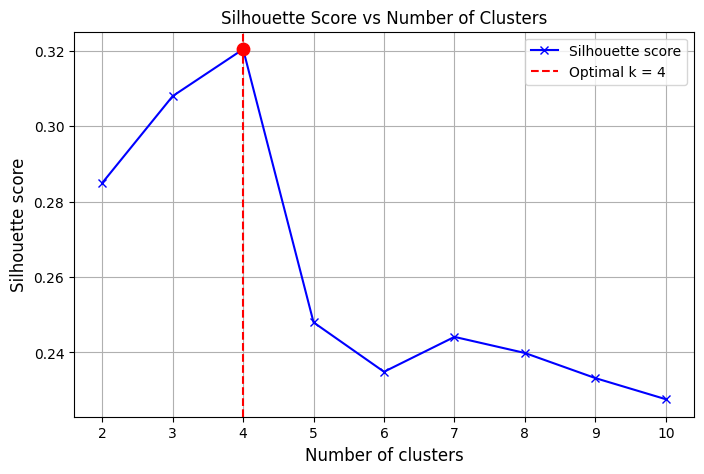

Оптимальное количество кластеров: 4 (силуэт: 0.320)


In [20]:
# Переберем количество кластеров в диапазоне от 3 до 9 включительно
def get_silhouette(cluster_num, X):
    k_model =  KMeans(
        n_clusters=cluster_num, 
        init='k-means++', 
        random_state=1)
    k_model.fit(X_pca)
    silhouette = silhouette_score(X_pca, k_model.labels_, metric='euclidean')
    return silhouette

silhouettes = []
cluster_range = range(2, 11) # Диапазон от 2 до 10 включительно

for i in cluster_range:
    silhouettes.append(get_silhouette(i, X_pca))

# Находим оптимальное количество кластеров
best_index = np.argmax(silhouettes)
best_k = cluster_range[best_index]
best_score = silhouettes[best_index]

# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouettes, 'xb-', label='Silhouette score')
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal k = {best_k}')
plt.scatter(best_k, best_score, color='red', s=80, zorder=5)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("Silhouette score", fontsize=12)
plt.title("Silhouette Score vs Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

# Выводим оптимальное количество кластеров
print(f"Оптимальное количество кластеров: {best_k} (силуэт: {best_score:.3f})")

<Axes: xlabel='K-Means_Cluster_ID', ylabel='child_mort'>

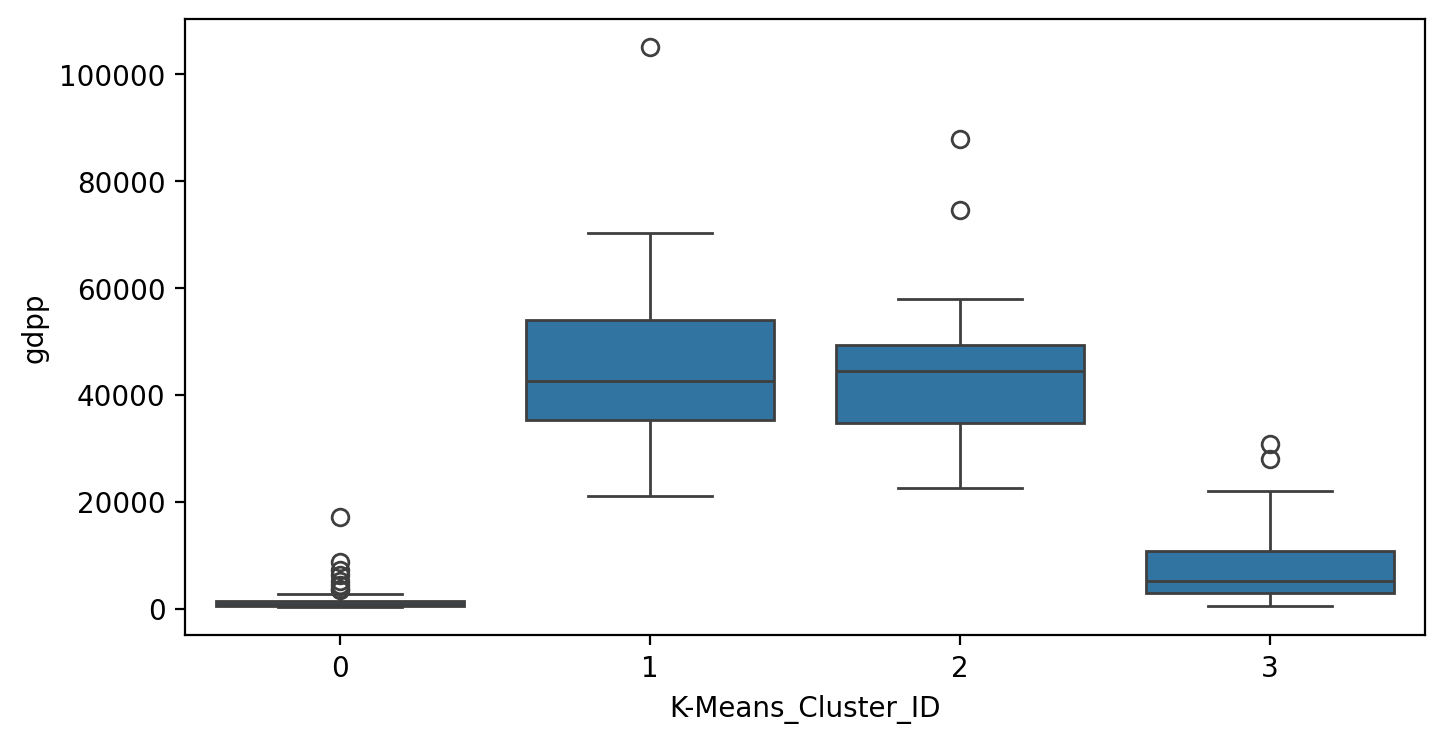

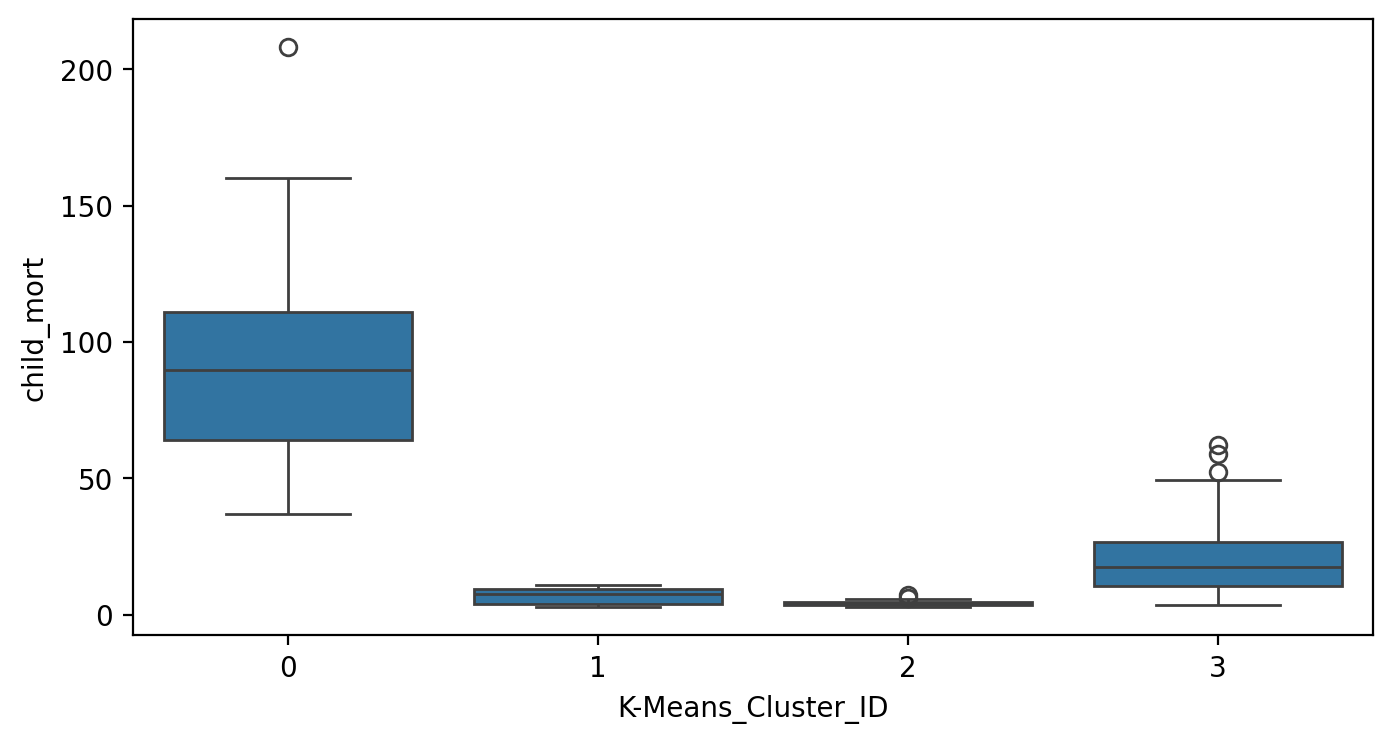

In [22]:
k_model =  KMeans(
        n_clusters=best_k,
        init='k-means++',
        random_state=1)
k_model.fit(X_pca)

# Получаем метки кластеров
country_data['K-Means_Cluster_ID'] = k_model.labels_
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID', y='gdpp', data=country_data)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID', y='child_mort', data=country_data)

In [ ]:
# Фильтруем данные по кластеру 0
cluster_1_countries = country_data[country_data['K-Means_Cluster_ID'] == 0]

# Сортируем по продолжительности жизни (по возрастанию)
lowest_life_expectancy = cluster_1_countries.sort_values(by='life_expec').head(3)

# Выводим страну, продолжительность жизни и кластер
print("Три страны из кластера 1 с наименьшей продолжительностью жизни:")
print(lowest_life_expectancy[['country', 'life_expec', 'K-Means_Cluster_ID']])

Три страны из кластера 1 с наименьшей продолжительностью жизни:
                     country  life_expec  K-Means_Cluster_ID
66                     Haiti        32.1                   0
87                   Lesotho        46.5                   0
31  Central African Republic        47.5                   0
